MODEL 1: CNN2D (basic for esp32)

In [12]:

import os, shutil, random, cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow : {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

SEED = 42 #random seed to not be change in every train loop
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Setup done")

TensorFlow : 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup done


In [13]:
import os, random, cv2
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

INPUT_DIR  = Path("/kaggle/input/datasets/akashshingha850/mrl-eye-dataset/data")
OUTPUT_DIR = Path("/kaggle/working/dataset_m1")

# Hàm giả lập IR ban đêm cho camera ESP32 
def simulate_ir(img_gray):
    factor = random.uniform(0.2, 0.5)
    img_dark = (img_gray * factor).astype(np.uint8)
    noise = np.random.normal(0, random.uniform(5, 20), img_dark.shape).astype(np.int16)
    img_noisy = np.clip(img_dark.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    img_ir = clahe.apply(img_noisy)
    return img_ir

CLASS_MAP = {"awake": "open", "sleepy": "closed"}

print("Bắt đầu xử lý và chuyển đổi dataset")
for split in ["train", "val", "test"]:
    for old_cls, new_cls in CLASS_MAP.items():
        src_dir  = INPUT_DIR / split / old_cls
        dest_dir = OUTPUT_DIR / split / new_cls
        
        dest_dir.mkdir(parents=True, exist_ok=True)
        
        if not src_dir.exists():
            print(f"Warning: Cant find {src_dir}")
            continue
            
        # Lấy tất cả ảnh
        imgs = list(src_dir.glob("*.png")) + list(src_dir.glob("*.jpg"))
        
        for i, src in enumerate(tqdm(imgs, desc=f"{split}/{new_cls}", leave=False)):
            img = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            dst = dest_dir / f"{new_cls}_{i:05d}.png"
            cv2.imwrite(str(dst), img)
            if split == "train" and random.random() < 0.1:
                img_ir = simulate_ir(img)
                dst_ir = dest_dir / f"{new_cls}_{i:05d}_ir.png"
                cv2.imwrite(str(dst_ir), img_ir)
                
        print(f"  [{split}/{new_cls}] Đã copy & xử lý: {len(list(dest_dir.glob('*'))):,} ảnh")

print("\nDONE preprocess")

Bắt đầu xử lý và chuyển đổi dataset


train/open:   0%|          | 0/25770 [00:00<?, ?it/s]

  [train/open] Đã copy & xử lý: 28,365 ảnh


train/closed:   0%|          | 0/25167 [00:00<?, ?it/s]

  [train/closed] Đã copy & xử lý: 27,717 ảnh


...

  [val/closed] Đã copy & xử lý: 8,389 ảnh


test/open:   0%|          | 0/8591 [00:00<?, ?it/s]

  [test/open] Đã copy & xử lý: 8,591 ảnh


test/closed:   0%|          | 0/8390 [00:00<?, ?it/s]

  [test/closed] Đã copy & xử lý: 8,390 ảnh

DONE preprocess


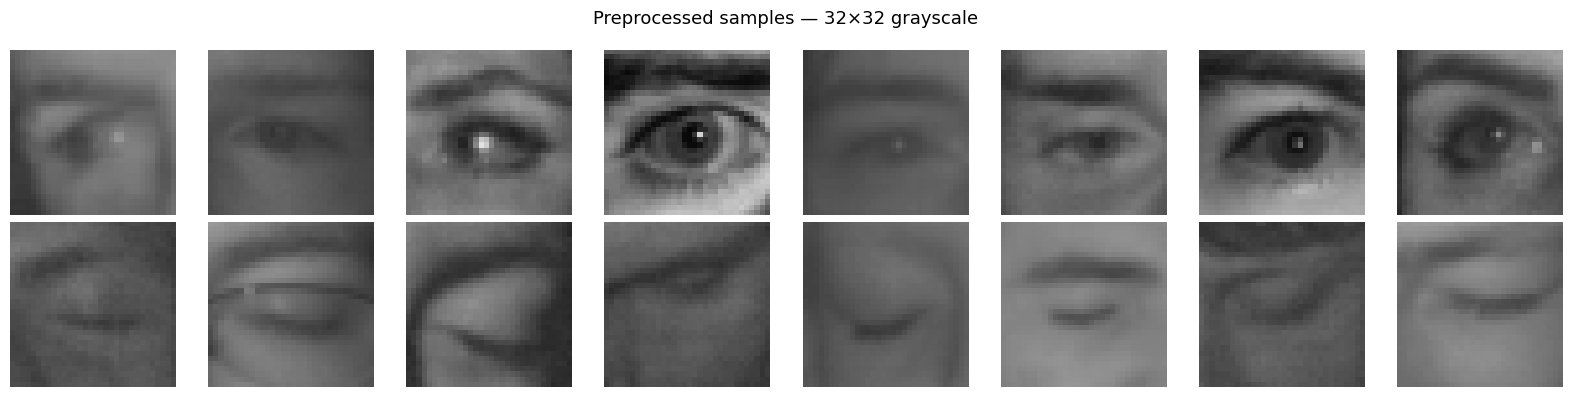

Preprocessing done


In [14]:
#CLAHE preprocessing and visual

IMG_SIZE = 32  

def preprocess_for_esp32(img_path):
    """
    Pipeline:
    1. Đọc grayscale (ESP32 gửi grayscale để tiết kiệm bandwidth)
    2. Auto-CLAHE nếu ảnh tối
    3. Resize 32x32
    4. Normalize [0, 1]
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    
    # Auto CLAHE
    mean_brightness = np.mean(img)
    if mean_brightness < 80:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        img = clahe.apply(img)
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return img.astype(np.float32) / 255.0


# Test visualize 
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for col, cls in enumerate(["open", "closed"]):
    imgs = list((OUTPUT_DIR / "train" / cls).glob("*"))[:8]
    for i, img_path in enumerate(imgs):
        processed = preprocess_for_esp32(img_path)
        axes[col][i].imshow(processed, cmap="gray", vmin=0, vmax=1)
        axes[col][i].axis("off")
        if i == 0:
            axes[col][i].set_ylabel(cls, fontsize=12, fontweight="bold")

plt.suptitle("Preprocessed samples — 32×32 grayscale", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/sample_preview.png", dpi=100)
plt.show()
print("Preprocessing done")

In [15]:
# TF Dataset pipeline

BATCH_SIZE = 128
AUTOTUNE   = tf.data.AUTOTUNE

def load_and_preprocess(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=1,
                                expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def apply_clahe_tf(img, label):
    def _clahe(img_tensor):
        img_np = (img_tensor.numpy() * 255).astype(np.uint8).squeeze()
        if np.mean(img_np) < 80:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
            img_np = clahe.apply(img_np)
        return (img_np.astype(np.float32) / 255.0).reshape(
            IMG_SIZE, IMG_SIZE, 1)

    img = tf.py_function(_clahe, [img], tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, label


def augment(img, label):
    """
    Augmentation pipeline
    """
    # 1. Flip ngang — mắt trái ↔ mắt phải
    img = tf.image.random_flip_left_right(img)

    # 2. Brightness — simulate ngày/đêm
    img = tf.image.random_brightness(img, max_delta=0.35)

    # 3. Contrast — simulate IR vs camera thường
    img = tf.image.random_contrast(img, lower=0.6, upper=1.4)

    # 4. Gaussian noise — simulate sensor noise ESP32-CAM và IR sensor noise ban đêm
    noise = tf.random.normal(shape=tf.shape(img),
                             mean=0.0, stddev=0.04)
    img = img + noise

    # 5. Random blur — simulate mất focus, đầu rung khi buồn ngủ
    #    Dùng tf.py_function wrap OpenCV blur
    def _blur(img_t):
        img_np = img_t.numpy().squeeze()
        if random.random() < 0.3:   # 30% bị blur
            k = random.choice([3, 5])
            img_np = cv2.GaussianBlur(img_np, (k, k), 0)
        return img_np.reshape(IMG_SIZE, IMG_SIZE, 1).astype(np.float32)

    img = tf.py_function(_blur, [img], tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 1])

    # 6. Random erasing — simulate tay/kính che 1 phần mắt
    #    Xóa 1 vùng nhỏ ngẫu nhiên trên ảnh
    def _erase(img_t):
        img_np = img_t.numpy()
        if random.random() < 0.25:  # 25% bị erase
            h, w   = IMG_SIZE, IMG_SIZE
            eh = random.randint(4, 10)  # chiều cao vùng xóa
            ew = random.randint(4, 10)  # chiều rộng vùng xóa
            y0 = random.randint(0, h - eh)
            x0 = random.randint(0, w - ew)
            # Thay bằng giá trị noise (tự nhiên hơn fill 0)
            fill = np.random.uniform(0, 0.3, (eh, ew, 1))
            img_np[y0:y0+eh, x0:x0+ew, :] = fill
        return img_np.astype(np.float32)

    img = tf.py_function(_erase, [img], tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 1])

    # Clip về [0, 1] sau tất cả augmentation
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def build_dataset(split, augment_data=False):
    CLASS_MAP = {"open": 0, "closed": 1}

    all_paths, all_labels = [], []
    for cls, label_idx in CLASS_MAP.items():
        folder = OUTPUT_DIR / split / cls
        paths  = [str(p) for p in folder.glob("*")
                  if p.suffix.lower() in {".jpg", ".png", ".jpeg"}]
        all_paths.extend(paths)
        all_labels.extend([label_idx] * len(paths))

    combined = list(zip(all_paths, all_labels))
    random.shuffle(combined)
    paths, labels = zip(*combined)

    ds = tf.data.Dataset.from_tensor_slices(
        (list(paths), list(labels)))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.map(apply_clahe_tf,      num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment,         num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds, len(paths)


train_ds, n_train = build_dataset("train", augment_data=True)
val_ds,   n_val   = build_dataset("val",   augment_data=False)
test_ds,  n_test  = build_dataset("test",  augment_data=False)

print(f"Datasets ready:")
print(f"   Train : {n_train:,} samples")
print(f"   Val   : {n_val:,} samples")
print(f"   Test  : {n_test:,} samples")

for imgs, labels in train_ds.take(1):
    print(f"\n   Batch shape : {imgs.shape}")
    print(f"   Label sample: {labels.numpy()[:8]}")

Datasets ready:
   Train : 56,082 samples
   Val   : 16,980 samples
   Test  : 16,981 samples

   Batch shape : (128, 32, 32, 1)
   Label sample: [0 0 0 1 0 0 0 1]


In [16]:
# CNN Architecture + SE Block

def se_block(x, ratio=4):
    """
    Squeeze-and-Excitation Block
    Cơ chế:
    1. Squeeze : GlobalAvgPool → tóm tắt mỗi channel thành 1 số
    2. Excite  : 2 lớp Dense học channel nào quan trọng
    3. Scale   : nhân weight vào từng channel của feature map
    """
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, filters))(se)
    se = layers.Dense(filters // ratio, activation="relu",
                      use_bias=False)(se)
    se = layers.Dense(filters, activation="sigmoid",
                      use_bias=False)(se)
    return layers.Multiply()([x, se])


def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1),
                         name="eye_image")

    # Block 1 — low-level: edges, eyelash texture
    x = layers.Conv2D(16, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = se_block(x, ratio=4)
    x = layers.MaxPooling2D(2)(x)        # 32→16
    x = layers.Dropout(0.1)(x)

    # Block 2 — mid-level: eyelid shape, iris boundary
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = se_block(x, ratio=4)
    x = layers.MaxPooling2D(2)(x)        # 16→8
    x = layers.Dropout(0.1)(x)

    # Block 3 — high-level: open/closed global pattern
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = se_block(x, ratio=8)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalAveragePooling2D()(x)

    # Classifier head
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation="softmax",
                           name="prediction")(x)

    return keras.Model(inputs, outputs, name="drowsiness_cnn_se")


model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

model.summary()

total_params = model.count_params()
size_kb_fp32 = total_params * 4 / 1024
size_kb_int8 = total_params * 1 / 1024

print(f"\nModel size estimate:")
print(f"   Params   : {total_params:,}")
print(f"   FP32 size: {size_kb_fp32:.1f} KB")
print(f"   INT8 size: {size_kb_int8:.1f} KB  ← export về ESP32")
print(f"   Target   : < 200 KB {'✅' if size_kb_int8 < 200 else '⚠️ Cần thu nhỏ model'}")

Model: "drowsiness_cnn_se"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eye_image           │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        144 │ eye_image[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ activation_3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1, 16)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1, 1, 4)   │         64 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1, 1, 16)  │         64 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (Multiply)          │ 16)               │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ multiply_3[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      4,608 │ dropout_4[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_4[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1, 1, 8)   │        256 │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1, 1, 32)  │        256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 16, 16,    │          0 │ activation_4[0][

 Total params: 27,442 (107.20 KB)

 Trainable params: 27,218 (106.32 KB)

 Non-trainable params: 224 (896.00 B)


Model size estimate:
   Params   : 27,442
   FP32 size: 107.2 KB
   INT8 size: 26.8 KB  ← export về ESP32
   Target   : < 200 KB ✅


In [17]:
# Training

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/best_model_m1.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print("Bắt đầu training...")
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining done!")
best_val_acc = max(history.history["val_accuracy"])
print(f"Best val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")


Bắt đầu training...
Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.6112 - loss: 0.6360
Epoch 1: val_accuracy improved from -inf to 0.59764, saving model to /kaggle/working/best_model_m1.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 163s 352ms/step - accuracy: 0.6114 - loss: 0.6358 - val_accuracy: 0.5976 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 2/50
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.8447 - loss: 0.3664
Epoch 2: val_accuracy improved from 0.59764 to 0.85518, saving model to /kaggle/working/best_model_m1.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 149s 340ms/step - accuracy: 0.8448 - loss: 0.3663 - val_accuracy: 0.8552 - val_loss: 0.3524 - learning_rate: 0.0010
Epoch 3/50
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8795 - loss: 0.2908
Epoch 3: val_accuracy improved from 0.85518 to 0.87721, saving model to /kaggle/working/best_model_m1.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 150s 342ms/step - accuracy: 0.8795 - loss: 0.2908 - val_accuracy: 0.8772 - v

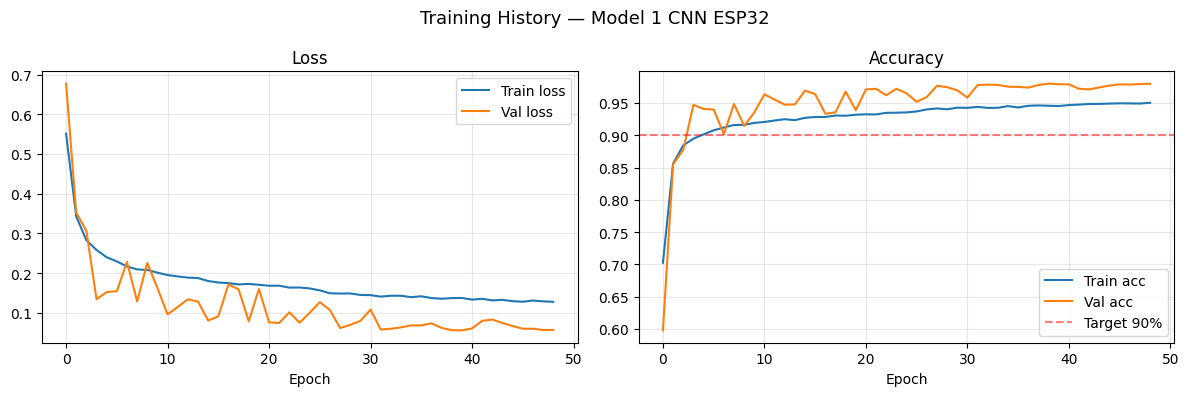

Evaluating on test set...
   Test accuracy: 0.9790 (97.9%)
   Test loss    : 0.0540

               precision    recall  f1-score   support

        open       0.98      0.97      0.98      8591
      closed       0.97      0.98      0.98      8390

    accuracy                           0.98     16981
   macro avg       0.98      0.98      0.98     16981
weighted avg       0.98      0.98      0.98     16981

Recall [closed]: 0.984 Pass (>= 90%)


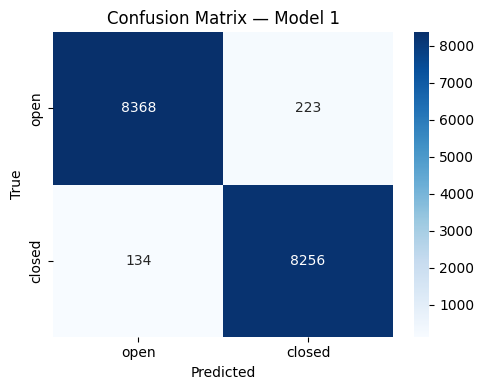


Exporting TFLite INT8...
INFO:tensorflow:Assets written to: /tmp/tmpcb9_dff8/assets


INFO:tensorflow:Assets written to: /tmp/tmpcb9_dff8/assets


Saved artifact at '/tmp/tmpcb9_dff8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='eye_image')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135520574432144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520574431952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520574428304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520574430032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520574431568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520574435408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520574435600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520570638800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520570640144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520570639952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135520570639568: Te

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1774958975.298062      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1774958975.298088      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Saved: eye_model_int8.tflite
Size : 43.0 KB  OK cho ESP32

Generating C header file...
Saved: eye_model.h

Download 2 files về máy:
eye_model_int8.tflite
eye_model.h


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [19]:
# Eval + plot + export

from sklearn.metrics import classification_report, confusion_matrix, recall_score
import seaborn as sns

#1.Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"],     label="Train loss")
ax1.plot(history.history["val_loss"], label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"],     label="Train acc")
ax2.plot(history.history["val_accuracy"], label="Val acc")
ax2.axhline(0.90, color="red", linestyle="--", alpha=0.5, label="Target 90%")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Training History — Model 1 CNN ESP32", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/training_history_m1.png", dpi=120)
plt.show()

# 2.Load best model + evaluate
model = keras.models.load_model("/kaggle/working/best_model_m1.keras")

print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"   Test accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"   Test loss    : {test_loss:.4f}")

# Classification report
y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\n", classification_report(y_true, y_pred, target_names=["open", "closed"]))

# Recall check
recall_closed = recall_score(y_true, y_pred, pos_label=1)
print(f"Recall [closed]: {recall_closed:.3f}",
      "Pass (>= 90%)" if recall_closed >= 0.90 else "Not reach 90%")

# ─── 3. Confusion matrix ─────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["open", "closed"],
            yticklabels=["open", "closed"])
plt.title("Confusion Matrix — Model 1")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_m1.png", dpi=120)
plt.show()

# Export TFLite INT8 
print("\nExporting TFLite INT8...")

def representative_dataset():
    for imgs, _ in train_ds.take(10):
        for img in imgs:
            yield [tf.expand_dims(img, 0)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8
converter.experimental_new_quantizer = True

tflite_model = converter.convert()

tflite_path = "/kaggle/working/eye_model_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"Saved: eye_model_int8.tflite")
print(f"Size : {size_kb:.1f} KB  {'OK cho ESP32' if size_kb < 200 else 'Quá lớn'}")

# 5.Export C header cho ESP32
print("\nGenerating C header file...")

hex_data = ", ".join([f"0x{b:02x}" for b in tflite_model])
c_header = f"""// Auto-generated by Kaggle training pipeline
// Model: Drowsiness CNN INT8 for ESP32-CAM
// Input : int8[1][32][32][1]  (grayscale 32x32)
// Output: int8[1][2]          (0=open, 1=closed)
// Size  : {size_kb:.1f} KB

#ifndef EYE_MODEL_H
#define EYE_MODEL_H

const unsigned char eye_model_tflite[] = {{
  {hex_data}
}};
const unsigned int eye_model_tflite_len = {len(tflite_model)};

#endif  // EYE_MODEL_H
"""

with open("/kaggle/working/eye_model.h", "w") as f:
    f.write(c_header)

print("Saved: eye_model.h")
print("\nDownload 2 files về máy:")
print("eye_model_int8.tflite")
print("eye_model.h")
